# Exercise 5 — Newton Optimization Method

## Theory

Newton's method can be used to find a local maximum or minimum of a function by searching for a critical point.

For this problem, the objective is to maximize the area function

$$
A(\theta)=4\sin(\theta)(1+\cos(\theta)).
$$

At a local maximum or minimum, the first derivative satisfies

$$
A'(\theta)=0.
$$

Therefore, the optimization problem can be transformed into a root-finding problem for $A'(\theta)$.

The first derivative of the area function is

$$
A'(\theta)
=
4\left[\cos(\theta)+\cos(2\theta)\right].
$$

The second derivative is

$$
A''(\theta)
=
4\left[-\sin(\theta)-2\sin(2\theta)\right].
$$

Newton's method applied to the equation $A'(\theta)=0$ gives the iterative formula

$$
\theta_{n+1}
=
\theta_n-
\frac{A'(\theta_n)}
{A''(\theta_n)}.
$$

Starting from an initial approximation $\theta_0$, the method generates successive approximations until the difference between two consecutive values satisfies the tolerance criterion

$$
|\theta_{n+1}-\theta_n|<\epsilon.
$$

Once the critical point is found, the sign of the second derivative can be used to determine its nature. If

$$
A''(\theta_{\mathrm{opt}})<0,
$$

the critical point corresponds to a local maximum.

The maximum area is then calculated as

$$
A_{\max}=A(\theta_{\mathrm{opt}}).
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Funcion de area
def area(theta):
  return 4*np.sin(theta)*(1+np.cos(theta))

# Primera derivada
def darea(theta):
  return 4*(np.cos(theta)+np.cos(2*theta))

# Segunda derivada
def ddarea(theta):
  return 4*(-np.sin(theta)-2*np.sin(2*theta))

# Parametros
theta = 0.8
epsilon = 0.0001

error = 1
iteracion = 0

while error >= epsilon:

  theta_nuevo = theta - darea(theta)/ddarea(theta)

  error = abs(theta_nuevo-theta)

  theta = theta_nuevo

  iteracion = iteracion+1

theta_opt = theta
area_max = area(theta_opt)

print("Iteraciones:",iteracion)
print("Theta optimo:",theta_opt)
print("Area maxima:",area_max)
print("Segunda derivada:",ddarea(theta_opt))

Iteraciones: 3
Theta optimo: 1.0471975511964853
Area maxima: 5.196152422706631
Segunda derivada: -10.392304845413939


In [2]:
theta_exact = 1.0472

error_verdadero = abs(theta_exact-theta_opt)
error_relativo = (error_verdadero/theta_exact)*100

print("Error verdadero:",error_verdadero)
print("Error relativo:",error_relativo,"%")

Error verdadero: 2.4488035146319476e-06
Error relativo: 0.00023384296358211877 %


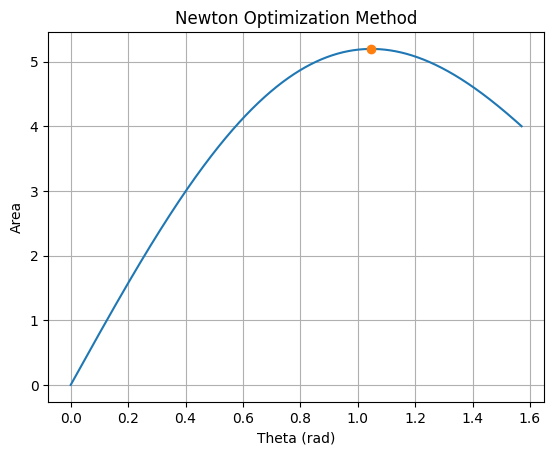

In [3]:
theta_valores = np.linspace(0,np.pi/2,1000)
A = area(theta_valores)

plt.plot(theta_valores,A)
plt.plot(theta_opt,area_max,'o')

plt.xlabel("Theta (rad)")
plt.ylabel("Area")
plt.title("Newton Optimization Method")
plt.grid()

plt.show()

## Conclusion

Newton's method was used to determine the value of $\theta$ that maximizes the area function

$$
A(\theta)=4\sin(\theta)(1+\cos(\theta)).
$$

The optimization problem was transformed into a root-finding problem by solving

$$
A'(\theta)=0.
$$

Using the first and second derivatives of the area function, Newton's iterative formula was applied until the difference between two consecutive approximations became smaller than the specified tolerance.

The condition

$$
A''(\theta_{\mathrm{opt}})<0
$$

confirms that the critical point obtained corresponds to a local maximum.

Unlike the Golden Section Search, Newton's method uses derivative information and can converge rapidly when the initial approximation is sufficiently close to the desired critical point.